In [1]:
import torch

In [4]:
%cd /home/robertflynn/Mimas/exp/exp4/acp21rjf/synthetic-asr-context/exp/

/home/robertflynn/Mimas/exp/exp4/acp21rjf/synthetic-asr-context/exp


In [5]:
!pwd

/home/robertflynn/Mimas/exp/exp4/acp21rjf/synthetic-asr-context/exp


In [6]:
!ls results_history/

gigaspeech_history_comparison.pdf   LS_history_7.txt
GS_history_0.txt		    LS_history_8.txt
GS_history_1.txt		    LS_history_9.txt
GS_history_2.txt		    LS_history_nP_10.txt
GS_history_3.txt		    LS_history_nP_11.txt
GS_history_4.txt		    LS_history_nP_12.txt
GS_history_5.txt		    LS_history_nP_13.txt
GS_history_6.txt		    LS_history_nP_14.txt
GS_history_7.txt		    LS_history_nP_15.txt
GS_history_nP_1.txt		    LS_history_nP_16.txt
GS_history_nP_2.txt		    LS_history_nP_17.txt
GS_history_nP_3.txt		    LS_history_nP_18.txt
GS_history_nP_4.txt		    LS_history_nP_19.txt
GS_history_nP_5.txt		    LS_history_nP_1.txt
GS_history_nP_6.txt		    LS_history_nP_20.txt
GS_history_nP_7.txt		    LS_history_nP_21.txt
GS_history_rsp_10.txt		    LS_history_nP_22.txt
GS_history_rsp_11.txt		    LS_history_nP_23.txt
GS_history_rsp_12.txt		    LS_history_nP_2.txt
GS_history_rsp_13.txt		    LS_history_nP_3.txt
GS_history_rsp_14.txt		    LS_history_nP_4.txt
GS_history_rsp_15.txt		    LS_history_nP_5.txt
GS_his

In [7]:
def get_wer_from_path(path):
    print(torch.load(path)['wer']*100)

def get_wer_from_txt_file(path):
    with open(path, 'r') as f:
        fi = f.read().splitlines()
    wer_lines = [el.strip() for el in fi if el.strip().startswith("Total WER:")]
    assert len(wer_lines) > 0
    last_line = wer_lines[-1]
    wer = float(last_line.split()[-1].strip('%'))
    return wer

def get_wer_per_history(preamble, min=0, max=8):
    wer_hist_dict = {}
    for i in range(min, max):
        path = f"{preamble}_{i}.txt"
        # print(path)
        wer = get_wer_from_txt_file(path)
        wer_hist_dict[i] = wer
    return wer_hist_dict

In [8]:
get_wer_per_history("./results_history/GS_history_nP", min=1, max=10)

FileNotFoundError: [Errno 2] No such file or directory: './results_history/GS_history_nP_8.txt'

In [9]:
get_wer_per_history("./results_history/GS_history_rsp_nP", min=1, max=16)

{1: 18.3789,
 2: 17.3893,
 3: 16.9501,
 4: 16.2888,
 5: 16.0445,
 6: 15.7467,
 7: 15.7014,
 8: 15.8032,
 9: 15.5693,
 10: 15.603,
 11: 15.6372,
 12: 15.3775,
 13: 15.328,
 14: 15.5626,
 15: 15.2418}

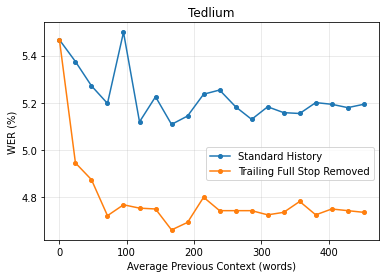

In [15]:
import matplotlib.pyplot as plt
GS_full = get_wer_per_history("./results_history/ted_history", max=20)
TED_full_nP = get_wer_per_history("./results_history/ted_history_nP", min=1, max=20)
TED_full_nP[0] = GS_full[0]  # Add back in the 0 history point for truncated context
# GS_trunc[0] = GS_full[0]  # Add back in the 0 history point for truncated context

with open('./tedlium.length.txt', 'r') as f:
    tedlium_avg_words = float(f.read().strip())

ted_x_full = [k * tedlium_avg_words for k in sorted(GS_full.keys())]
ted_x_np = [k * tedlium_avg_words for k in sorted(TED_full_nP.keys())]

plt.plot(ted_x_full, [GS_full[k] for k in sorted(GS_full.keys())], label='Standard History', marker='o',markersize=4)
plt.plot(ted_x_np, [TED_full_nP[k] for k in sorted(TED_full_nP.keys())], label='Trailing Full Stop Removed', marker='o',markersize=4)
ax=plt.gca()
ax.grid(True, axis='both', alpha=0.3)
ax.axvline(224, color='red', linestyle='--', linewidth=1.5, label='Whisper cache limit (224)')
# plt.plot(sorted(list(GS_trunc.keys())), [GS_trunc[k] for k in sorted(GS_trunc.keys())], label='truncated context', marker='o')
plt.xlabel('Average Previous Context (words)')
plt.ylabel('WER (%)')
plt.title('Tedlium')
plt.legend(loc='center right', bbox_to_anchor=(1, 0.35))
plt.savefig('tedlium_history_comparison.pdf', bbox_inches='tight')
plt.show()


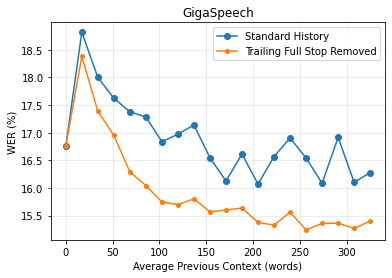

In [16]:
import matplotlib.pyplot as plt
GS_full = get_wer_per_history("./results_history/GS_history", min=0)
GS_trunc = get_wer_per_history("./results_history/GS_history_rsp", min=1, max=20)
GS_trunc_nP = get_wer_per_history("./results_history/GS_history_rsp_nP", min=1, max=20)
GS_trunc[0] = GS_full[0]  # Add back in the 0 history point for truncated context
GS_trunc_nP[0] = GS_full[0]  # Add back in the 0 history point for truncated context

with open('./gigaspeech.length.txt', 'r') as f:
    gigaspeech_avg_words = float(f.read().strip())

gs_x_trunc = [k * gigaspeech_avg_words for k in sorted(GS_trunc.keys())]
gs_x_trunc_np = [k * gigaspeech_avg_words for k in sorted(GS_trunc_nP.keys())]

# plt.plot(sorted(list(GS_full.keys())), [GS_full[k] for k in sorted(GS_full.keys())], label='full context', marker='o')
plt.plot(gs_x_trunc, [GS_trunc[k] for k in sorted(GS_trunc.keys())], label='Standard History', marker='o')
plt.plot(gs_x_trunc_np, [GS_trunc_nP[k] for k in sorted(GS_trunc_nP.keys())], label='Trailing Full Stop Removed', marker='o', markersize=4)
ax=plt.gca()
ax.grid(True, axis='both', alpha=0.3)
ax.axvline(224, color='red', linestyle='--', linewidth=1.5, label='Whisper cache limit (224)')
plt.xlabel('Average Previous Context (words)')
plt.ylabel('WER (%)')
plt.title('GigaSpeech')
plt.legend()
plt.savefig('gigaspeech_history_comparison.pdf', bbox_inches='tight')
plt.show()


In [17]:
GS_full

{0: 16.7558,
 1: 19.1018,
 2: 18.2146,
 3: 17.8264,
 4: 17.1537,
 5: 17.9119,
 6: 16.8012,
 7: 16.8604}

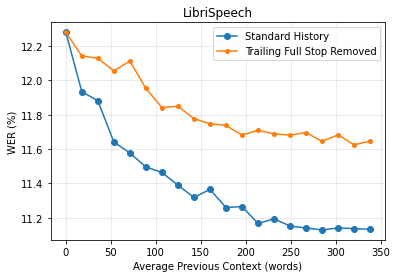

In [18]:
import matplotlib.pyplot as plt
GS_full = get_wer_per_history("./results_history/LS_history", max=20)
LS_full_np = get_wer_per_history("./results_history/LS_history_nP", min=1, max=20)
LS_full_np[0] = GS_full[0]  # Add back in the
# GS_trunc = get_wer_per_history("./results_history/LS_history_rsp", min=1)

with open('./librispeech.length.txt', 'r') as f:
    librispeech_avg_words = float(f.read().strip())

ls_x_full = [k * librispeech_avg_words for k in sorted(GS_full.keys())]
ls_x_np = [k * librispeech_avg_words for k in sorted(LS_full_np.keys())]

plt.plot(ls_x_full, [GS_full[k] for k in sorted(GS_full.keys())], label='Standard History', marker='o')
plt.plot(ls_x_np, [LS_full_np[k] for k in sorted(LS_full_np.keys())], label='Trailing Full Stop Removed', marker='o', markersize=4)
ax = plt.gca()
ax.grid(True, axis='both', alpha=0.3)
ax.axvline(224, color='red', linestyle='--', linewidth=1.5, label='Whisper cache limit (224)')
# plt.plot(sorted(list(GS_trunc.keys())), [GS_trunc[k] for k in sorted(GS_trunc.keys())], label='truncated context', marker='o')
plt.xlabel('Average Previous Context (words)')
plt.ylabel('WER (%)')
plt.title('LibriSpeech')
plt.legend()
plt.savefig('librispeech_history_comparison.pdf', bbox_inches='tight')
plt.show()


In [68]:
get_wer_from_path('./results/results_cross_utt/whisper_turbo_GS_TS_b5.pt')

FileNotFoundError: [Errno 2] No such file or directory: './results/results_cross_utt/whisper_turbo_GS_TS_b5.pt'

In [30]:
a = torch.load("result_longform/whisper_turbo_tedllium_b5_H_ts.pt")

In [31]:
a['hyps'][3]

"I'm Jane McGonigal. I'm a game designer. I've been making games online now for 10 years, and my goal for the next decade is to try to make it as easy to save the world in real life as it is to save the world in online games. Now, I have a plan for this, and it entails convincing more people, including all of you, to spend more time playing bigger and better games. Right now, we spend 3 billion hours a week playing online games. Some of you might be thinking, that's a lot of time to spend playing games, maybe too much time, considering how many urgent problems we have to solve in the real world. But actually, according to my research at the Institute for the Future, it's actually the opposite is true. 3 billion hours a week is not nearly enough gameplay to solve the world's most urgent problems. In fact, I believe that if we want to survive the next century on this planet, we need to increase that total dramatically. I've calculated the total we need at 21 billion hours of gameplay eve